In [17]:
#UNDERSTANDING A DATASET

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# df = pd.read_csv("/content/drive/MyDrive/AML_MSIS/titanic.csv")
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/refs/heads/master/titanic.csv"
df = pd.read_csv(url)

print(df.head())


#Number of rows and columns
print("\nShape : ",df.shape)

#Column names
print("\n Columns :\n", df.columns.tolist())

#Data Types
print("\n Data Types :\n" ,df.dtypes)

#Statistical Summary
print("\n Statistical Summary:\n",df.describe())

#Categorical Columns
print("\nCategorical Columns :\n" ,df.select_dtypes(include = 'object').columns.tolist())

#Numerical Columns
print("\n Numerical Columns : \n", df.select_dtypes(include = np.number).columns.tolist())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  

S

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
             Missing Count   Missing Percentage 
PassengerId               0             0.000000
Survived                  0             0.000000
Pclass                    0             0.000000
Name                      0             0.000000
Sex                       0             0.000000
Age                     177            19.865320
SibSp                     0             0.000000
Parch                     0             0.000000
Ticket                    0             0.000000
Fare                      0             0.000000
Cabin                   687            77.104377
Embarked                  2             0.224467


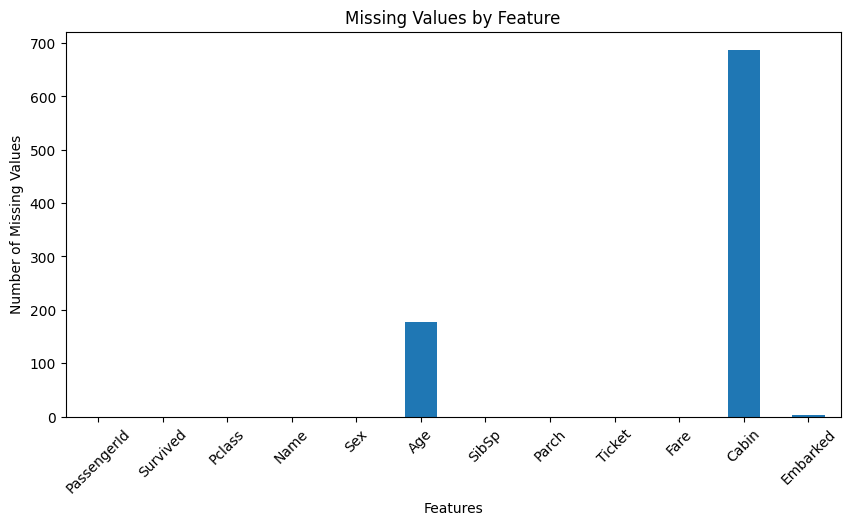

Duplicate rows: 0


In [19]:
#DATA QUALITY ANALYSIS

missing = df.isnull().sum()

print(missing)

missing_per = (df.isnull().sum() / len (df)) * 100

missing_table = pd.DataFrame({"Missing Count ":missing,
                              "Missing Percentage ":missing_per
                              })

print(missing_table)

plt.figure(figsize=(10, 5))
df.isnull().sum().plot(kind='bar')
plt.title("Missing Values by Feature")
plt.xlabel("Features")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation = 45)
plt.show()

print("Duplicate rows:", df.duplicated().sum())

In [29]:
#REPLACE MISSING VALUES BY MEAN

df_mean = df.copy()

mean_age = df_mean['Age'].mean()

df_mean['Age'] = df_mean['Age'].fillna(mean_age)

print("\nRemaining Missing Age Values : \n", df_mean['Age'].isnull().sum())

#REPLACE MISSING VALUES BY MEDIAN

df_median = df.copy()

median_age = df_median['Age'].median()

df_median['Age'] = df_median['Age'].fillna(median_age)

print("\nRemaining Missing Age Values : \n", df_median['Age'].isnull().sum())

print("\nMean Age : ",df['Age'].mean(),"\nMedian Age : ",df['Age'].median())

#REPLACE MISSING VALUES BY MODE - Categorical
df_mode = df.copy()

mode_embarked = df_mode['Embarked'].mode()[0]

df_mode['Embarked'] = df_mode['Embarked'].fillna(mode_embarked)

print("\nRemaining Missing embarked Values : \n", df_mode['Embarked'].isnull().sum())



Remaining Missing Age Values : 
 0

Remaining Missing Age Values : 
 0

Mean Age :  29.69911764705882 
Median Age :  28.0

Remaining Missing embarked Values : 
 0


In [34]:
#ENCODING - ONE HOT ENCODER

display(df[['Sex','Embarked']].head(10))

from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    sparse_output= False,
    handle_unknown='ignore'
    )

encoded = encoder.fit_transform(df[['Sex','Embarked']])

encoded_df = pd.DataFrame(
    encoded,
    columns = encoder.get_feature_names_out(['Sex', 'Embarked'])
)

display(encoded_df.head())


#ENCODING - LABEL


from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Survived_encoded'] = le.fit_transform(df['Survived'])

display(df[['Survived', 'Survived_encoded']].head())

,Sex,Embarked
0,male,S
1,female,C
2,female,S
3,female,S
4,male,S
5,male,Q
6,male,S
7,male,S
8,female,S
9,female,C


,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Embarked_nan
0,0.0,1.0,0.0,0.0,1.0,0.0
1,1.0,0.0,1.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,1.0,0.0
3,1.0,0.0,0.0,0.0,1.0,0.0
4,0.0,1.0,0.0,0.0,1.0,0.0


,Survived,Survived_encoded
0,0,0
1,1,1
2,1,1
3,1,1
4,0,0


In [38]:
#FEATURE SCALING - MIN MAX

features = df[['Age','Fare']].dropna()

display(features.describe())

from sklearn.preprocessing import MinMaxScaler

minmax = MinMaxScaler()

scaled_minmax = minmax.fit_transform(features)

minmax_df = pd.DataFrame(scaled_minmax,
                         columns=['Age', 'Fare']
                         )
display(minmax_df.head())

#FEATURE SCALING - STANDARDIZATION

from sklearn.preprocessing import StandardScaler

sd = StandardScaler()

scaled_standard = sd.fit_transform(features)

sd_df = pd.DataFrame(
    scaled_standard,
    columns = ['Age', 'Fare']
)

display(sd_df.head())

,Age,Fare
count,714.000000,714.000000
mean,29.699118,34.694514
std,14.526497,52.918930
min,0.420000,0.000000
25%,20.125000,8.050000
50%,28.000000,15.741700
75%,38.000000,33.375000
max,80.000000,512.329200


,Age,Fare
0,0.271174,0.014151
1,0.472229,0.139136
2,0.321438,0.015469
3,0.434531,0.103644
4,0.434531,0.015713


,Age,Fare
0,-0.530377,-0.518978
1,0.571831,0.691897
2,-0.254825,-0.506214
3,0.365167,0.348049
4,0.365167,-0.503850
